# GDP Analysis — Part 1: Dataset Walkthrough & GDP Growth Calculation

Gross Domestic Product (GDP) measures the overall economic performance of a country. This notebook:

1. Walks through the raw World Bank GDP dataset
2. Derives a new metric — **year-over-year GDP growth (%)** — for a single country, step by step
3. Generalizes that calculation across all 256 countries in the dataset, and saves the result for reuse in later notebooks

**GDP growth formula:**
```
GDP growth % = (GDP this year − GDP last year) / GDP last year × 100
```

## 1. Dataset Walkthrough

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('data/gdp.csv')
df.head()

,Country Name,Country Code,Year,Value
0,Arab World,ARB,1968,2.576068e+10
1,Arab World,ARB,1969,2.843420e+10
2,Arab World,ARB,1970,3.138550e+10
3,Arab World,ARB,1971,3.642691e+10
4,Arab World,ARB,1972,4.331606e+10


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11507 entries, 0 to 11506
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  11507 non-null  str    
 1   Country Code  11507 non-null  str    
 2   Year          11507 non-null  int64  
 3   Value         11507 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 359.7 KB


In [4]:
# Confirm no missing values
df.isnull().sum()

Country Name    0
Country Code    0
Year            0
Value           0
dtype: int64

In [5]:
# How many unique countries and years are in the dataset
df.nunique()

Country Name      256
Country Code      256
Year               57
Value           11398
dtype: int64

In [6]:
df['Year'].describe()

count    11507.000000
mean      1991.265230
std         15.886648
min       1960.000000
25%       1978.000000
50%       1993.000000
75%       2005.000000
max       2016.000000
Name: Year, dtype: float64

**Dataset:** 11,507 rows covering 256 countries/regions (including aggregates like "World" and "Arab World"), with GDP values (`Value`, in current US$) recorded per year. Year coverage varies by country — most have close to the full 1960–2016 range, but some have as few as 2 years recorded.

## 2. GDP Growth — Working Through One Country

Before generalizing to the whole dataset, it helps to work the calculation through by hand for a single country: **Arab World**.

In [7]:
df_pr = df[df['Country Name'] == 'Arab World']
df_pr.head()

,Country Name,Country Code,Year,Value
0,Arab World,ARB,1968,2.576068e+10
1,Arab World,ARB,1969,2.843420e+10
2,Arab World,ARB,1970,3.138550e+10
3,Arab World,ARB,1971,3.642691e+10
4,Arab World,ARB,1972,4.331606e+10


<Axes: title={'center': 'Arab World GDP (1968–2016)'}, xlabel='Year'>

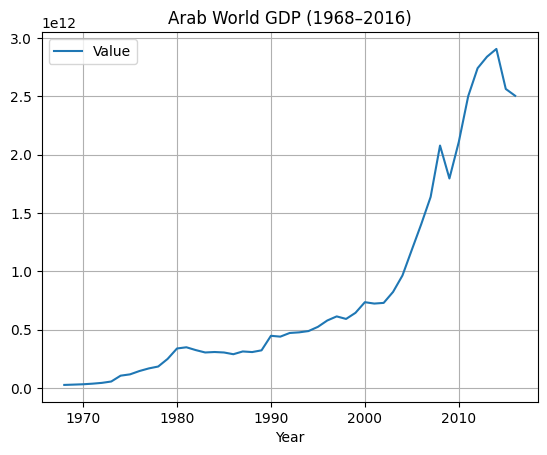

In [8]:
df_pr.plot(kind='line', x='Year', y='Value', grid=True, title='Arab World GDP (1968–2016)')

**Working the formula manually for the first few years:**
```
1968 → 1969: (28,434,203,615 − 25,760,683,041) / 25,760,683,041 × 100 = 10.38%
1969 → 1970: (31,385,500,000 − 28,434,203,615) / 28,434,203,615 × 100 = 10.38%
```
Now let's apply this across every consecutive year pair in the `Arab World` data.

In [9]:
data = df_pr.values

# data[i][3] is the 'Value' (GDP) column for row i
for i in range(1, len(data)):
    prev = data[i-1][3]
    cur = data[i][3]
    growth = round(((cur - prev) / prev) * 100, 2)
    print(int(data[i][2]), '→', growth, '%')

1969 → 10.38 %
1970 → 10.38 %
1971 → 16.06 %
1972 → 18.91 %
1973 → 27.02 %
1974 → 91.11 %
1975 → 10.64 %
1976 → 24.51 %
1977 → 15.51 %
1978 → 9.71 %
1979 → 35.46 %
1980 → 36.01 %
1981 → 3.08 %
1982 → -6.96 %
1983 → -6.28 %
1984 → 1.31 %
1985 → -1.31 %
1986 → -4.89 %
1987 → 8.18 %
1988 → -1.66 %
1989 → 4.82 %
1990 → 38.64 %
1991 → -1.59 %
1992 → 7.14 %
1993 → 1.14 %
1994 → 2.31 %
1995 → 7.43 %
1996 → 10.4 %
1997 → 6.06 %
1998 → -3.55 %
1999 → 8.85 %
2000 → 14.15 %
2001 → -1.6 %
2002 → 0.8 %
2003 → 12.9 %
2004 → 17.1 %
2005 → 22.91 %
2006 → 18.52 %
2007 → 16.63 %
2008 → 26.9 %
2009 → -13.58 %
2010 → 17.48 %
2011 → 18.58 %
2012 → 9.58 %
2013 → 3.59 %
2014 → 2.36 %
2015 → -11.81 %
2016 → -2.29 %


In [10]:
# Store the growth values in a list, with 0 for the first year (no prior year to compare against)
gdp_change = [0]

for i in range(1, len(data)):
    prev = data[i-1][3]
    cur = data[i][3]
    gdp_change.append(round(((cur - prev) / prev) * 100, 2))

df_pr = df_pr.assign(GDP_Growth=gdp_change)
df_pr.head()

,Country Name,Country Code,Year,Value,GDP_Growth
0,Arab World,ARB,1968,2.576068e+10,0.00
1,Arab World,ARB,1969,2.843420e+10,10.38
2,Arab World,ARB,1970,3.138550e+10,10.38
3,Arab World,ARB,1971,3.642691e+10,16.06
4,Arab World,ARB,1972,4.331606e+10,18.91


## 3. Generalizing GDP Growth to Every Country

Now the same logic is applied to all 256 countries at once, looping through each one, computing growth for its own year sequence, and merging the results back into a single dataframe.

In [11]:
growth_frames = []

for country_name in df['Country Name'].unique():
    country_df = df[df['Country Name'] == country_name]
    data = country_df.values
    gdp_change = [0]

    for i in range(1, len(data)):
        prev = data[i-1][3]
        cur = data[i][3]
        gdp_change.append(round(((cur - prev) / prev) * 100, 2))

    country_df = country_df.assign(GDP_Growth=gdp_change)
    growth_frames.append(country_df)

df_with_growth = pd.concat(growth_frames, axis=0)
df_with_growth.head()

,Country Name,Country Code,Year,Value,GDP_Growth
0,Arab World,ARB,1968,2.576068e+10,0.00
1,Arab World,ARB,1969,2.843420e+10,10.38
2,Arab World,ARB,1970,3.138550e+10,10.38
3,Arab World,ARB,1971,3.642691e+10,16.06
4,Arab World,ARB,1972,4.331606e+10,18.91


In [12]:
# Spot-check: confirm the shape matches the original dataset (no rows lost or duplicated)
df_with_growth.shape, df.shape

((11507, 5), (11507, 4))

Saving the result so later notebooks don't need to recompute this from scratch.

In [13]:
df_with_growth.to_csv('data/gdp_with_growth.csv', index=False)